FITS 文件结构信息:
Filename: /data1/R10000FITS/Z-2.4/lte02300-0.20-2.4.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (212027,)   float64   



Header 关键参数:
----------------------------------------
PHXTEFF  : 2300.0 K
PHXLOGG  : 0.2
PHXM_H   : -2.399999999999999
CRVAL1   : Not found (log wavelength start)
CDELT1   : Not found (wavelength step)
NAXIS1   : 212027 (number of wavelength points)

数据概览:
----------------------------------------
总点数: 212027
波长范围: 3000.00 Å ~ 24999.92 Å
前5个通量值: [2327786.1375 2246771.5625 2149017.5375 2031209.5875 1893908.1375]
最后5个通量值: [1.84021696e+12 1.84091898e+12 1.83764176e+12 1.82667706e+12
 1.80566082e+12]


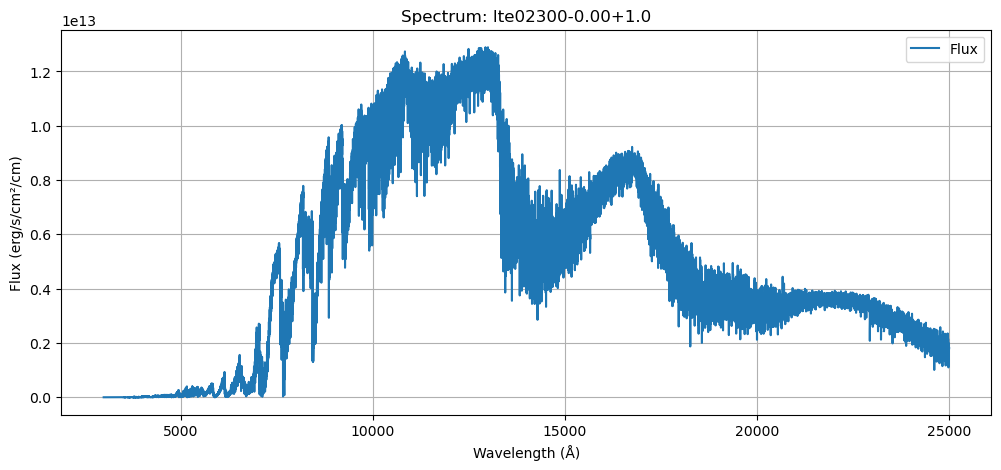

In [3]:
from astropy.io import fits
import numpy as np

# 文件路径
file_path = "/data1/R10000FITS/Z-2.4/lte02300-0.20-2.4.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"

# 打开 FITS文件
with fits.open(file_path) as hdul:
    # 显示文件基本信息
    print("FITS 文件结构信息:")
    print("=" * 40)
    hdul.info()
    print("=" * 40)

    # 获取主HDU的数据和header
    header = hdul[0].header
    flux = hdul[0].data

    # 显示 Header 中的关键参数
    print("\nHeader 关键参数:")
    print("-" * 40)
    print(f"PHXTEFF  : {header.get('PHXTEFF', 'Not found')} K")
    print(f"PHXLOGG  : {header.get('PHXLOGG', 'Not found')}")
    print(f"PHXM_H   : {header.get('PHXM_H', 'Not found')}")
    print(f"CRVAL1   : {header.get('CRVAL1', 'Not found')} (log wavelength start)")
    print(f"CDELT1   : {header.get('CDELT1', 'Not found')} (wavelength step)")
    print(f"NAXIS1   : {header.get('NAXIS1', 'Not found')} (number of wavelength points)")

    # 计算波长数组（以埃为单位）
    crval1 = header.get('CRVAL1', 8.006368)
    cdelt1 = header.get('CDELT1', 1.0E-05)
    naxis1 = header.get('NAXIS1', len(flux))

    wavelength_log = crval1 + cdelt1 * np.arange(naxis1)
    wavelength = np.exp(crval1 + cdelt1 * np.arange(naxis1)) # 转换为线性波长（埃）

    # 显示数据维度和前几个点的值
    print("\n数据概览:")
    print("-" * 40)
    print(f"总点数: {len(flux)}")
    print(f"波长范围: {wavelength[0]:.2f} Å ~ {wavelength[-1]:.2f} Å")
    print(f"前5个通量值: {flux[:5]}")
    print(f"最后5个通量值: {flux[-5:]}")

    # 可选：绘制光谱图
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 5))
    plt.plot(wavelength, flux, label='Flux')
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux (erg/s/cm²/cm)")
    plt.title("Spectrum: lte02300-0.00+1.0")
    plt.grid(True)
    plt.legend()
    plt.show()